# 7. Кластеризація на основі графу найближчих сусідів (KNN)

Цей метод будує граф k-найближчих сусідів (KNN-граф), де кожна точка з'єднана з k найближчими сусідами. Потім виконується агломеративна кластеризація з урахуванням структури графу. Це дозволяє виявляти кластери складної форми, враховуючи локальну щільність даних.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.data_loader import create_scaled, subsample
from src.visualization import plot_cluster_scatter_2d, plot_silhouette_curve
from src.evaluation import compute_metrics, find_best_k, build_results_row, save_results
from src.clustering import run_knn_clustering, get_cluster_profiles

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv(PROCESSED_PATH)
with open(TOP_PAIRS_PATH) as f:
    pairs = json.load(f)

n_sample = SAMPLE_SIZES['knn']
df_sub = subsample(df, n_sample)
print(f"Дані: {df.shape[0]} рядків")
print(f"Підвибірка: {df_sub.shape[0]} рядків")
print(f"Пари для кластеризації: {pairs}")
N = len(pairs)

Дані: 89741 рядків
Підвибірка: 10000 рядків
Пари для кластеризації: [['loudness', 'speechiness'], ['loudness', 'valence'], ['speechiness', 'valence'], ['energy', 'loudness']]


## 7.1 Вплив параметра n_neighbors

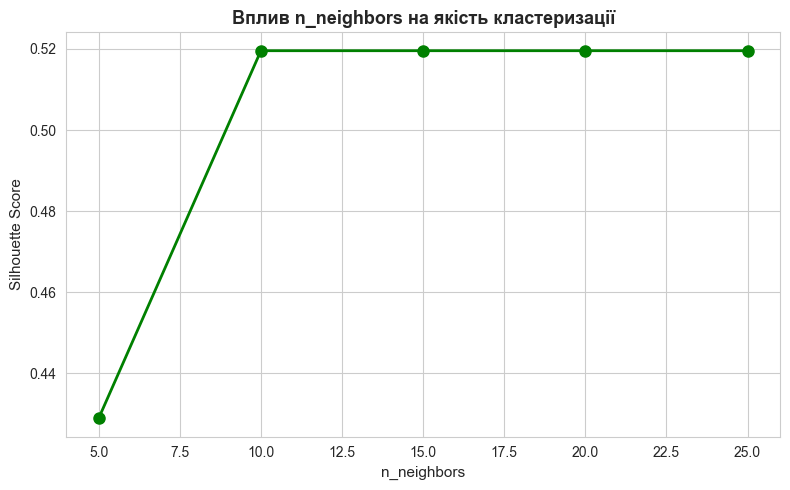

Пара: loudness + speechiness
  n_neighbors= 5: Silhouette=0.4289
  n_neighbors=10: Silhouette=0.5196 <-- найкращий
  n_neighbors=15: Silhouette=0.5196
  n_neighbors=20: Silhouette=0.5196
  n_neighbors=25: Silhouette=0.5196

Використовуємо n_neighbors=10


In [3]:
X_test, _ = create_scaled(df_sub, pairs[0])
X_test_arr = X_test.values

neighbor_values = [5, 10, 15, 20, 25]
sil_by_neighbors = []
for nn in neighbor_values:
    labels, _ = run_knn_clustering(X_test_arr, k=5, n_neighbors=nn)
    m = compute_metrics(X_test_arr, labels)
    sil_by_neighbors.append(m['silhouette'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(neighbor_values, sil_by_neighbors, 'go-', linewidth=2, markersize=8)
ax.set_xlabel('n_neighbors', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title('Вплив n_neighbors на якість кластеризації', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_nn = neighbor_values[np.argmax(sil_by_neighbors)]
print(f"Пара: {pairs[0][0]} + {pairs[0][1]}")
for nn, s in zip(neighbor_values, sil_by_neighbors):
    marker = ' <-- найкращий' if nn == best_nn else ''
    print(f"  n_neighbors={nn:2d}: Silhouette={s:.4f}{marker}")
print(f"\nВикористовуємо n_neighbors={KNN_N_NEIGHBORS}")

## 7.2 Підбір оптимального k

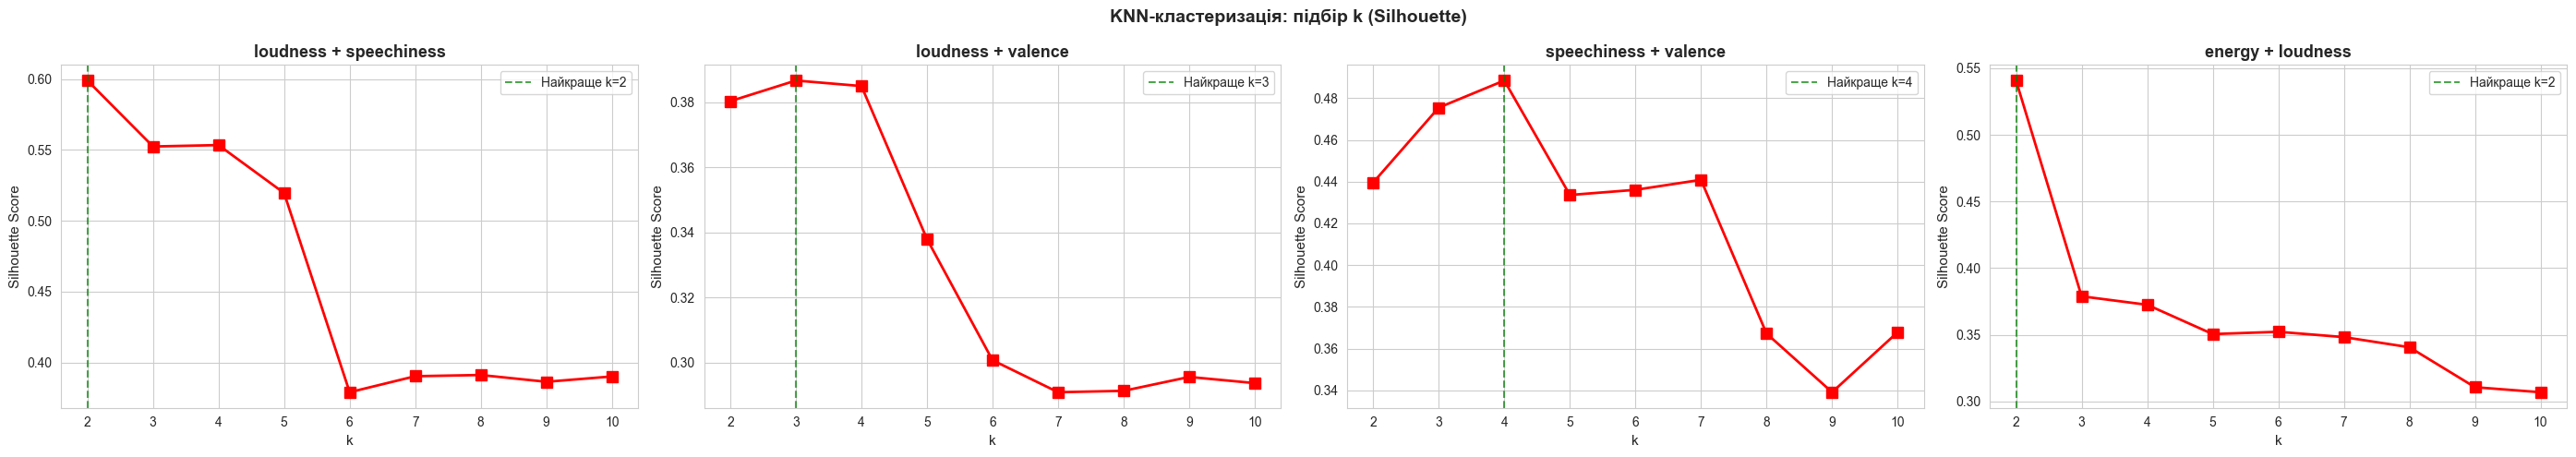

loudness + speechiness: найкращий k = 2
loudness + valence: найкращий k = 3
speechiness + valence: найкращий k = 4
energy + loudness: найкращий k = 2


In [4]:
best_k = {}

fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

for j, pair in enumerate(pairs):
    X_scaled, _ = create_scaled(df_sub, pair)
    X_arr = X_scaled.values

    def fit_fn(X, k):
        labels, _ = run_knn_clustering(X, k, n_neighbors=KNN_N_NEIGHBORS)
        return labels

    bk, scores = find_best_k(X_arr, K_RANGE, fit_fn)
    best_k[j] = bk
    plot_silhouette_curve(K_RANGE, scores, f'{pair[0]} + {pair[1]}', ax=axes[j])

plt.suptitle('KNN-кластеризацiя: пiдбiр k (Silhouette)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for j, pair in enumerate(pairs):
    print(f"{pair[0]} + {pair[1]}: найкращий k = {best_k[j]}")

## 7.3 Кластеризація пар та 2D-візуалізація

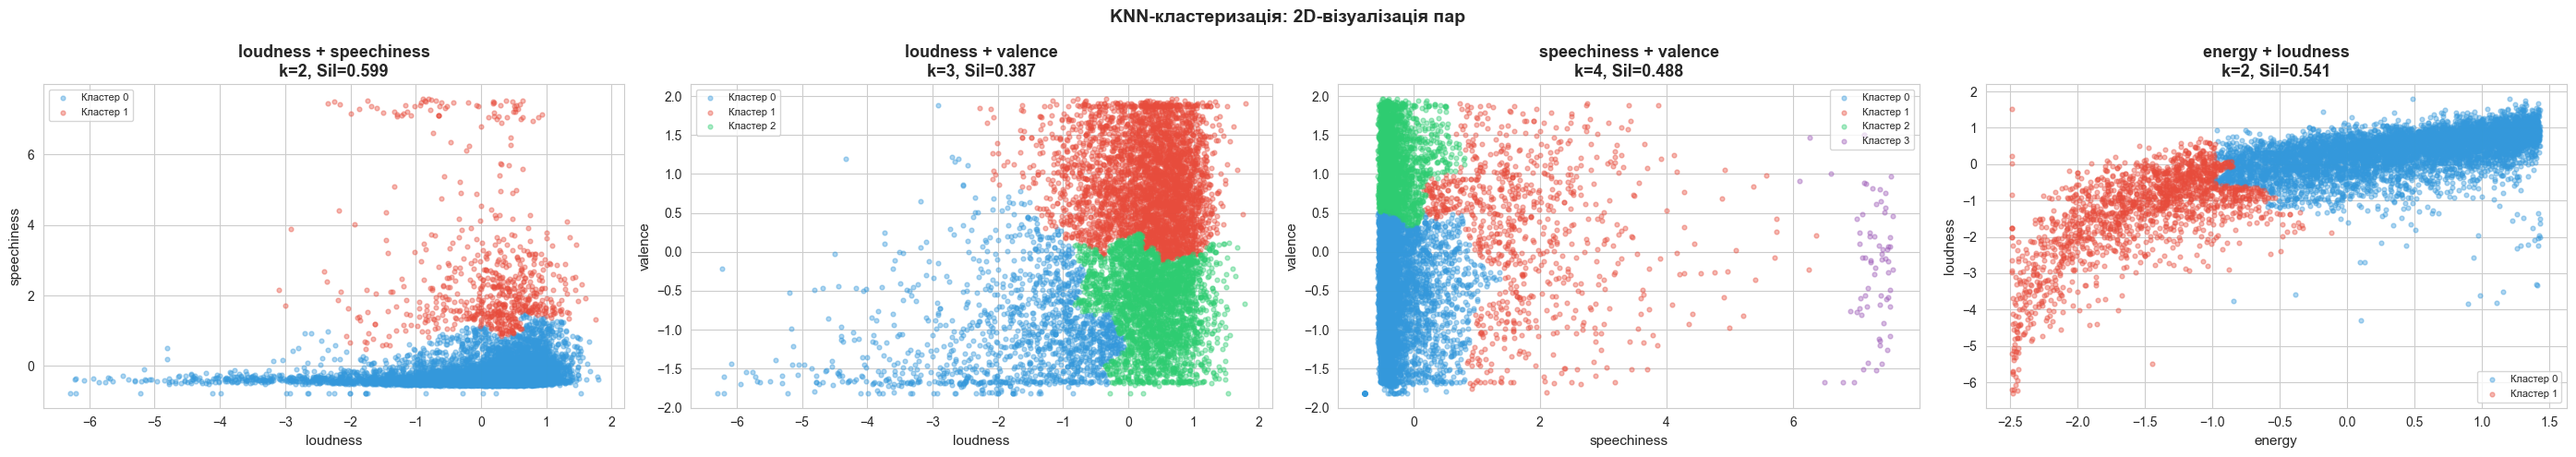

,algorithm,pair,k,silhouette,davies_bouldin,time_sec
0,KNN-clustering,loudness + speechiness,2,0.598919,0.832792,1.5745
1,KNN-clustering,loudness + valence,3,0.386724,0.851778,1.4169
2,KNN-clustering,speechiness + valence,4,0.488456,0.680420,0.9279
3,KNN-clustering,energy + loudness,2,0.540771,0.702690,1.1470


In [5]:
results = []
pair_labels = {}

fig, axes = plt.subplots(1, N, figsize=(7 * N, 5))
if N == 1:
    axes = [axes]

for j, pair in enumerate(pairs):
    X_scaled, _ = create_scaled(df_sub, pair)
    X_arr = X_scaled.values
    k = best_k[j]

    start = time.time()
    labels, _ = run_knn_clustering(X_arr, k, n_neighbors=KNN_N_NEIGHBORS)
    pair_labels[j] = labels
    elapsed = time.time() - start

    metrics = compute_metrics(X_arr, labels)
    pair_name = f'{pair[0]} + {pair[1]}'
    results.append(build_results_row('KNN-clustering', pair_name, k, metrics, elapsed))

    plot_cluster_scatter_2d(
        X_arr, labels, pair,
        f'{pair_name}\nk={k}, Sil={metrics["silhouette"]:.3f}',
        ax=axes[j]
    )

plt.suptitle('KNN-кластеризація: 2D-візуалізація пар', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pd.DataFrame(results)

## 7.4 Жанровий склад кластерiв

Аналiз розподiлу музичних жанрiв мiж кластерами для кожної пари ознак.

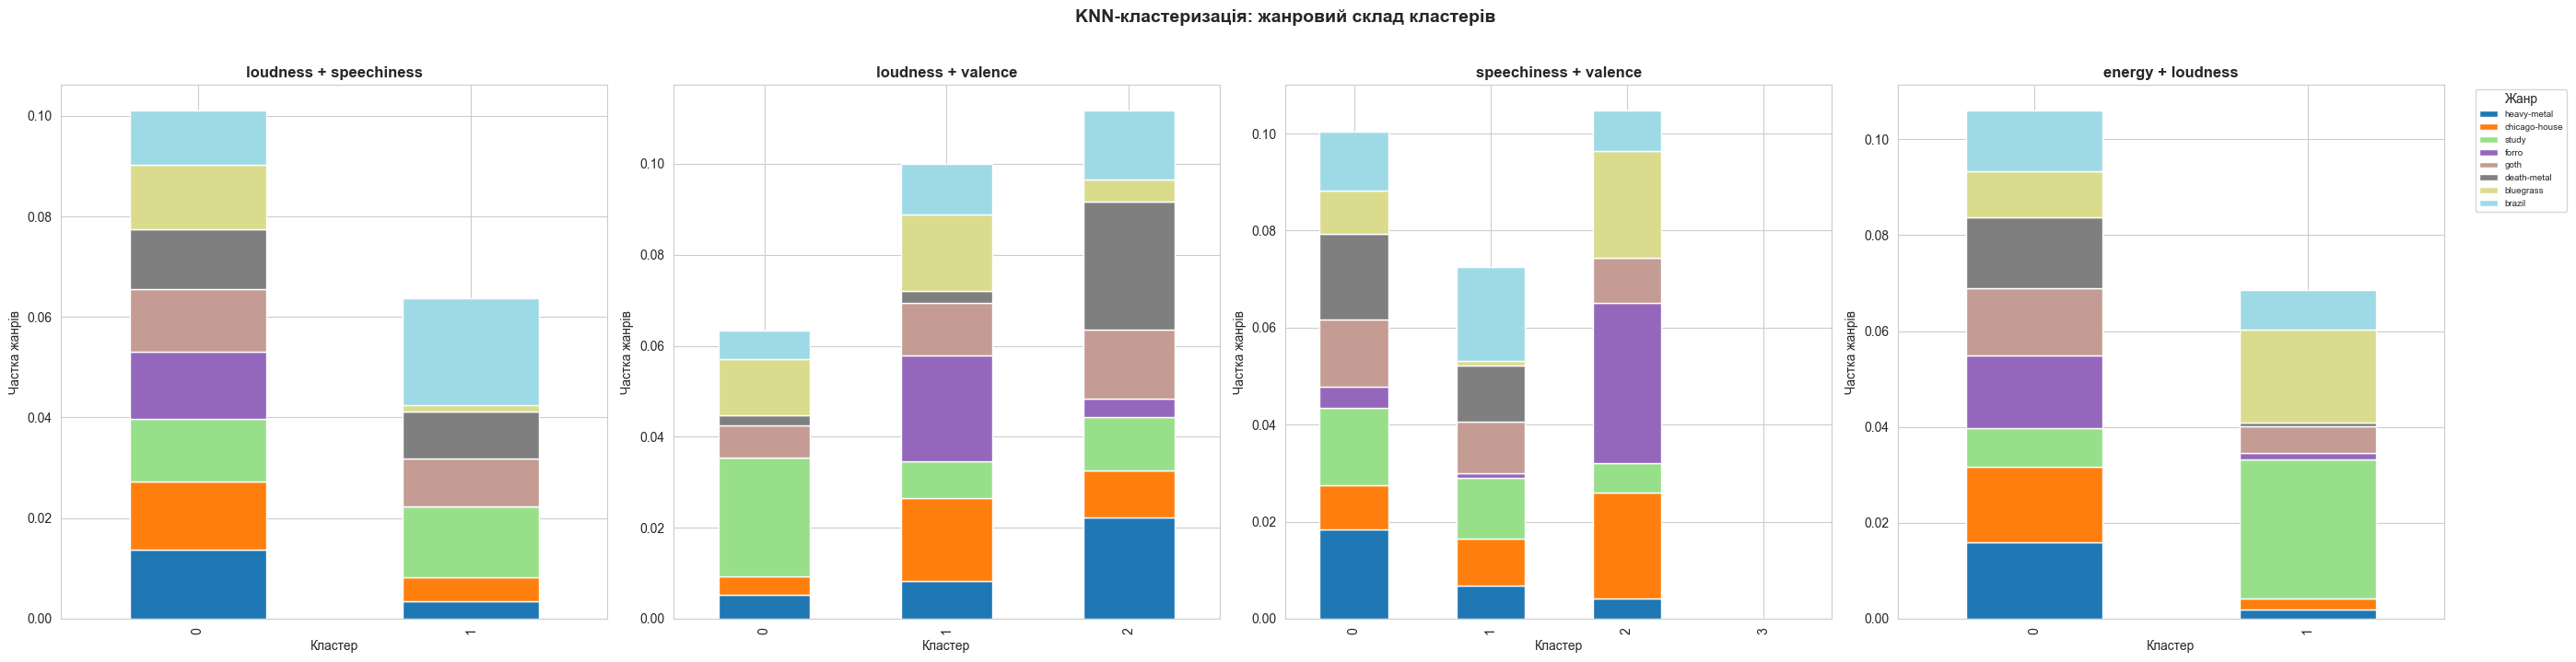

In [6]:
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 7))
if len(pairs) == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    df_temp = df_sub.copy()
    df_temp['cluster'] = pair_labels[i]
    top_genres = df_sub[GENRE_COL].value_counts().head(8).index
    genre_ct = pd.crosstab(df_temp['cluster'], df_temp[GENRE_COL], normalize='index')
    cols = [c for c in top_genres if c in genre_ct.columns]
    genre_ct[cols].plot(kind='bar', stacked=True, ax=axes[i], colormap='tab20', legend=False)
    axes[i].set_title(f'{pair[0]} + {pair[1]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel('Частка жанрiв')

axes[-1].legend(title='Жанр', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.suptitle('KNN-кластеризацiя: жанровий склад кластерiв', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
save_results(results, 'results_knn.csv')
pd.DataFrame(results)

Результати збережено: F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\results_knn.csv


,algorithm,pair,k,silhouette,davies_bouldin,time_sec
0,KNN-clustering,loudness + speechiness,2,0.598919,0.832792,1.5745
1,KNN-clustering,loudness + valence,3,0.386724,0.851778,1.4169
2,KNN-clustering,speechiness + valence,4,0.488456,0.680420,0.9279
3,KNN-clustering,energy + loudness,2,0.540771,0.702690,1.1470


## Пiдсумок

**KNN-графова кластеризацiя** використовує граф k-найближчих сусiдiв як обмеження зв'язностi для агломеративної кластеризацiї.

**Переваги:**
- Враховує локальну структуру даних через граф сусiдiв
- Здатна знаходити кластери неопуклої форми
- Параметр `n_neighbors` дозволяє контролювати ступiнь зв'язностi графу

**Недолiки:**
- Повiльнiше за k-Means через побудову графу
- Потребує пiдбору двох параметрiв: k (кiлькiсть кластерiв) та n_neighbors

**Результати:** метод показав здатнiсть враховувати локальну щiльнiсть, що дає iншi межi кластерiв порiвняно зi стандартним iєрархiчним пiдходом.